# Indentification of Candidate Datasets

Dataset 1

Name: Airbnb Prices in European Cities (Hugging Face / Zenodo). Originally from Tourism Management (2021).

Course Topic Alignment: Clustering, Anomaly Detection
Beyond-Course Technique: Spatial Analysis

Size: 100K AirBnb accommodation offers

Data Types: 
* city: the city of the offer,
* realSum: the full price of accommodation for two people and two nights in EUR,
* room_type: the type of the accommodation,
* room_shared: dummy variable for shared rooms,
* room_private: dummy variable for private rooms,
* person_capacity: the maximum number of guests,
* host_is_superhost: dummy variable for superhost status,
* multi: dummy variable if the listing belongs to hosts with 2-4 offers,
* biz: dummy variable if the listing belongs to hosts with more than 4 offers,
* cleanliness_rating: cleanliness rating,
* guest_satisfaction_overall: overall rating of the listing,
* bedrooms: number of bedrooms (0 for studios),
* dist: distance from city centre in km,
* metro_dist: distance from nearest metro station in km,
* attr_index: attraction index of the listing location,
* attr_index_norm: normalised attraction index (0-100),
* rest_index: restaurant index of the listing location,
* attr_index_norm: normalised restaurant index (0-100),
* lng: longitude of the listing location,
* lat: latitude of the listing location

Licence: Creative Commons Attribution 4.0 International



Dataset 2

Amazon Product Reviews (Text & Sentiment)
Dataset Name & Source: Amazon Product Reviews (Kaggle / McAuley Lab)

Course Topic Alignment: Text Mining (TF-IDF, Tokenization) and Clustering (grouping similar reviews).

Potential Beyond-Course Techniques: Transformer-based Embeddings (BERT/RoBERTa) for advanced sentiment analysis or Aspect-Based Sentiment Analysis (ABSA) to extract specific product features (e.g., "battery life" vs. "screen").

Dataset Size & Structure: 571.54M reviews

Data Types: Unstructured Text (Review Content), Float (Star Rating), Categorical (Product Category), String (User/Product IDs).

Target Variable(s): Rating (1-5 stars) or Sentiment (Positive/Negative).

Licensing: Public Domain / CC BY-NC-SA.

Dataset 3
Yelp Academic Dataset (Graph Mining)
Dataset Name & Source: Yelp Open Dataset (KDD / Yelp Official)

Course Topic Alignment: Graph Mining, PageRank, and Community Detection (identifying clusters of socially connected users).

Potential Beyond-Course Techniques: Graph Neural Networks (GNNs) for node classification or Link Prediction to suggest new friends or business visits.

Dataset Size & Structure: Multi-GB JSON files containing 1M+ users and businesses. Structured as relational data (Users, Businesses, Reviews).

Data Types: Adjacency Lists (User-User friends), Geographic Coordinates (Lat/Long), Text (Reviews), Integer (Check-ins).

Target Variable(s): Elite Status (Binary), Business Rating (Regression), or Category (Classification).

Licensing: Yelp Dataset Terms of Use (Academic Use Only).

# Comparative Analysis of Datasets

| Comparison Dimension | Airbnb European Prices | Amazon Product Reviews | Yelp Academic Dataset |
|----------------------|------------------------|------------------------|-----------------------|
| **Supported Data Mining Tasks** | **Course:** Clustering, Anomaly Detection<br>**External:** Spatial Econometrics, Geographically Weighted Regression | **Course:** Text Mining, Frequent Itemsets<br>**External:** Transformer Embeddings (BERT), Aspect Extraction | **Course:** Graph Mining, Community Detection<br>**External:** Graph Neural Networks (GNN), Link Prediction |
| **Data Quality Issues** | **High Quality:** Cleaned academic dataset<br>**Missing Features:** No textual reviews (only numerical ratings) | **Noisy Text:** Sarcasm, misspellings, non-English reviews<br>**Fake Reviews:** Bot-generated content may skew sentiment | **Sparsity:** User-user graph highly sparse (many users have 0 friends)<br>**Complexity:** JSON format requires significant preprocessing |
| **Algorithmic Feasibility** | **Easy:** Tabular data fits into memory (Pandas); spatial calculations fast | **Medium:** NLP on large corpora computationally expensive (GPU needed for BERT) | **Hard:** Graph algorithms (PageRank on 1M+ nodes) may require Spark or optimized libraries (NetworkX, PyG) |
| **Bias Considerations** | **Tourism Bias:** Focus on tourist zones, may ignore residential realities | **Selection Bias:** Reviews often polarized (very happy or very angry users) | **Geographic Bias:** Concentrated in metropolitan areas; rural underrepresented |
| **Ethical Considerations** | **Gentrification:** Short-term rental analysis relates to housing affordability and displacement | **Privacy:** Reviews may contain PII<br>**Manipulation:** Fake review detection impacts reputations | **Surveillance:** User movement/check-in analysis raises privacy concerns<br>**Doxxing:** Risk of re-identification |

# Dataset Selection

Selected Dataset: Airbnb Prices in European Cities

**Justification**

We have selected the Airbnb dataset for three primary reasons:

1. Strong Alignment with Course Topics: The dataset is ideal for clustering (identifying high-value vs. budget neighborhoods) and anomaly detection (spotting listings with irregular pricing strategies or outlier characteristics). 

2. Unique Opportunity for Spatial Analysis: Unlike the Amazon or Yelp datasets, this dataset includes precise geospatial coordinates (Latitude/Longitude). This allows us to implement Spatial Econometrics (specifically Geographically Weighted Regression or Moran’s I for spatial autocorrelation) as our "beyond-course" technique. This adds a dimension of analysis—physical geography—that is not standard in many text or graph mining projects.

3. Data Cleanliness & Feasibility: The data is already pre-processed for academic use (published in Tourism Management). This significantly reduces the time required for data cleaning (handling broken JSON or scraping HTML) and allows us to focus our efforts on implementing complex algorithms and interpreting results.

**Trade-offs**

By choosing this dataset, we accept the following limitations:

1. No Textual Analysis: The dataset lacks the raw text of user reviews. This means we cannot perform Natural Language Processing (NLP) tasks such as sentiment analysis or topic modeling, which were strong features of the Amazon and Yelp datasets.

2. Limited Scope: The data is restricted to 10 specific European cities during a specific timeframe (weekdays vs. weekends). It may not generalize to global markets or long-term temporal trends (e.g., seasonal changes across a full year).

# Exploratory Data Analysis For Choosen Dataset

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# load the dataset of amsterdam weekdays
df = pd.read_csv('../data/amsterdam_weekdays.csv') 

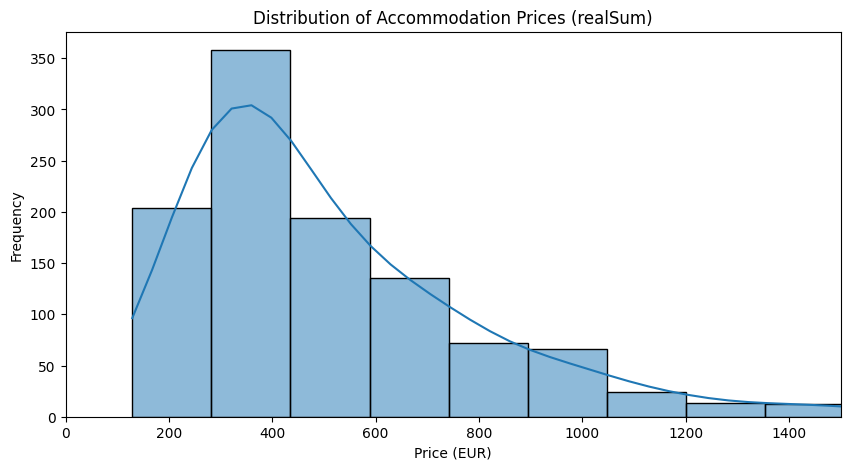

In [19]:
plt.figure(figsize=(10, 5))
sns.histplot(df['realSum'], bins=50, kde=True)
plt.title('Distribution of Accommodation Prices (realSum)')
plt.xlabel('Price (EUR)')
plt.ylabel('Frequency')
plt.xlim(0, 1500) # Limiting x-axis to zoom in, assuming there are high outliers
plt.show()

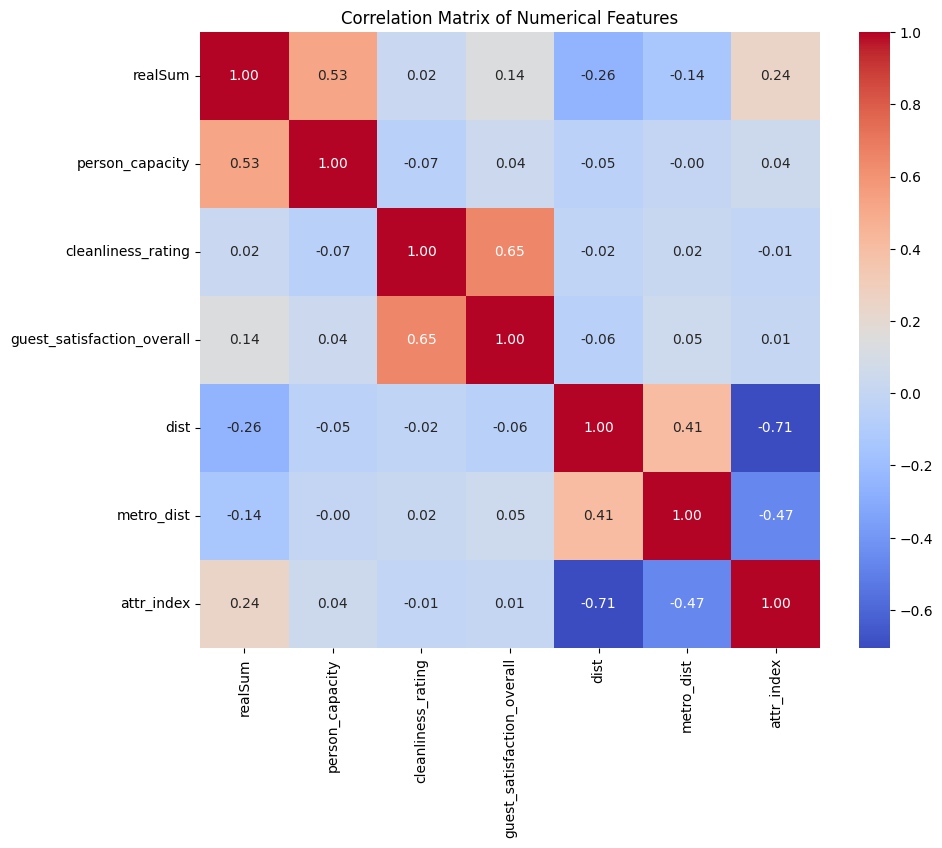

In [20]:
numerical_cols = ['realSum', 'person_capacity', 'cleanliness_rating', 
                  'guest_satisfaction_overall', 'dist', 'metro_dist', 'attr_index']
corr_matrix = df[numerical_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Numerical Features')
plt.show()

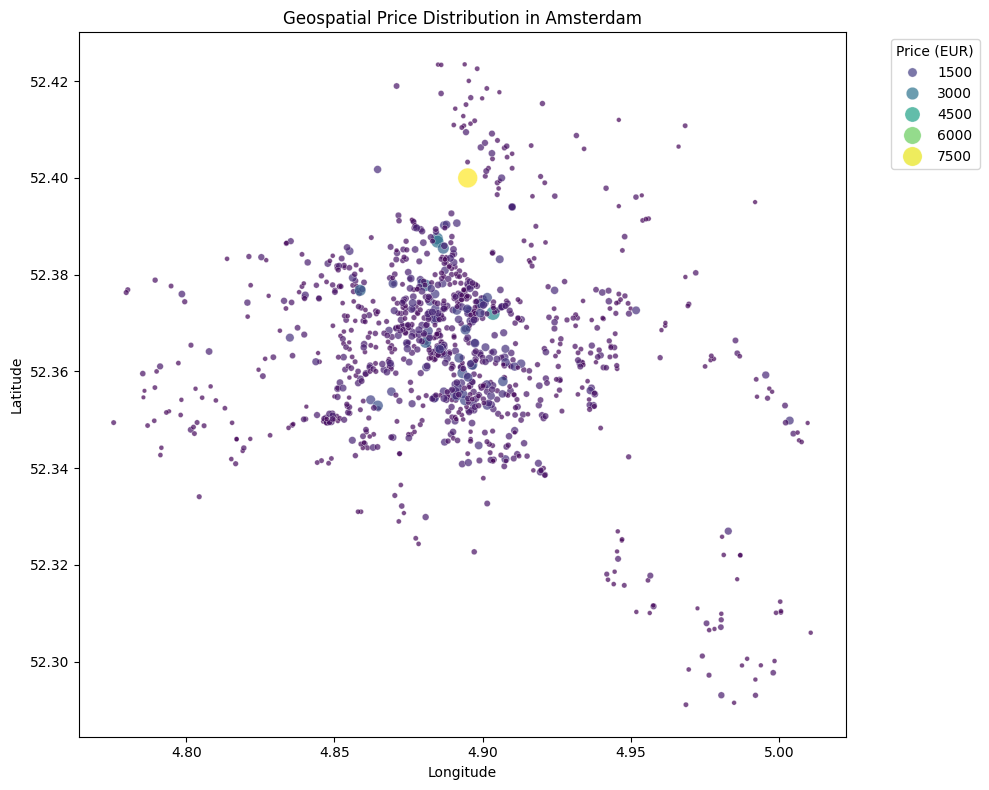

In [21]:
city_to_plot = 'Amsterdam'

plt.figure(figsize=(10, 8))
sns.scatterplot(
    data=df, 
    x='lng', y='lat', 
    hue='realSum', size='realSum',
    sizes=(10, 200), palette='viridis', alpha=0.7
)
plt.title(f'Geospatial Price Distribution in {city_to_plot}')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.legend(title='Price (EUR)', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

/tmp/ipykernel_10124/1056747311.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='room_type', y='realSum', palette='Set3', showfliers=False)


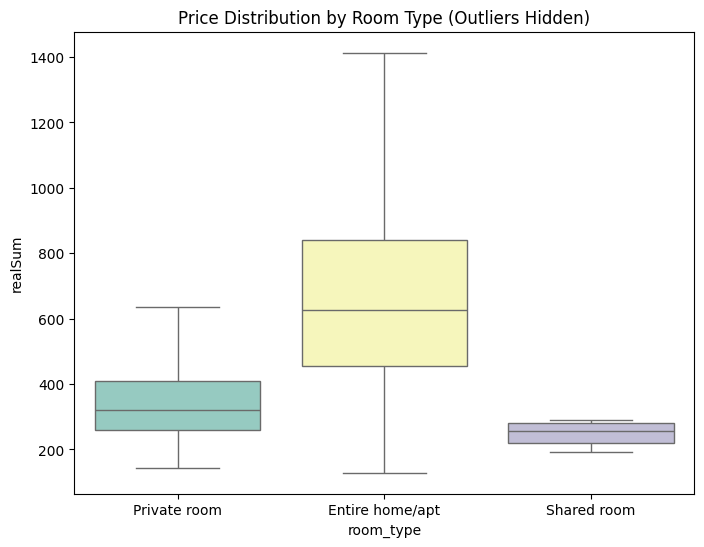

In [23]:
plt.figure(figsize=(8, 6))
sns.boxplot(data=df, x='room_type', y='realSum', palette='Set3', showfliers=False)
plt.title('Price Distribution by Room Type (Outliers Hidden)')
plt.show()

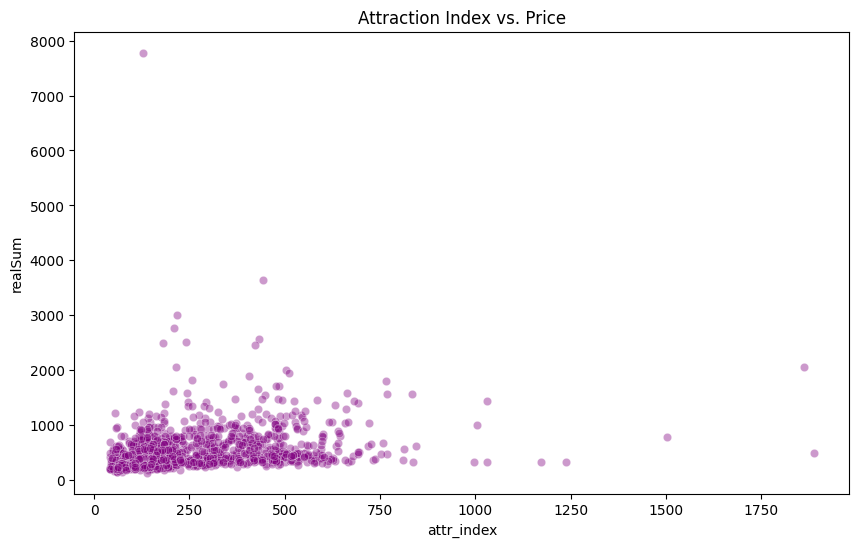

In [ ]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='attr_index', y='realSum', alpha=0.4, color='purple')
plt.title('Attraction Index vs. Price')
plt.show()

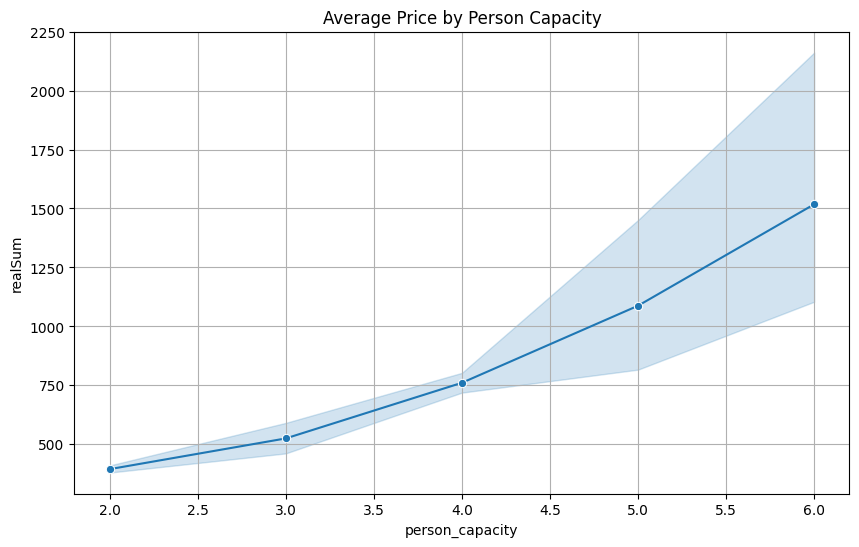

In [28]:
plt.figure(figsize=(10, 6))
sns.lineplot(data=df, x='person_capacity', y='realSum', marker='o')
plt.title('Average Price by Person Capacity')
plt.grid(True)
plt.show()

# Insights

Observations:
* There is a strong negative correlation between the attraction index and the distence of the center square
* Attraction index has a slight impact of price
* Having an entire house/apt is more expensive compared to a private room or shared room
* guest satisfaction has a strong correlation with cleaness

Hypothesis:
* Becasue Amsterdam is a walkable city, the attraction index doesn't have a strong impact on the price, because it would be possible to walk to the ceneter square with out much issue.

Potentail RQs:
* Would less walkable cities would have an attraction index that better correlates with price?
* Would capacity have much more of an inpact with cities with less space like New york.

## Citings

Collaborators:
* ...

Web Sources:
* https://huggingface.co/datasets/kraina/airbnb#data-fields
* https://zenodo.org/records/4446043#.ZEV8d-zMI-R
* https://www.kaggle.com/datasets/wajahat1064/amazon-reviews-data-2023
* https://www.kaggle.com/datasets/yelp-dataset/yelp-dataset
* https://business.yelp.com/data/resources/open-dataset/

AI Tools:
* Gemini:
    * found the amazon and yelp datasets
    * help write A/B/C
    * listed usfual eda

Citations:
* Gyódi, K., & Nawaro, Ł. (2021). Determinants of Airbnb prices in European cities: A spatial econometrics approach (Supplementary Material) [Data set]. Zenodo. https://doi.org/10.5281/zenodo.4446043
